<a href="https://colab.research.google.com/github/yansiercaro/alura_store/blob/main/AluraStoreLatam.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Importación de datos



In [17]:
import pandas as pd

url = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_1%20.csv"
url2 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_2.csv"
url3 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_3.csv"
url4 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_4.csv"

tienda = pd.read_csv(url)
tienda2 = pd.read_csv(url2)
tienda3 = pd.read_csv(url3)
tienda4 = pd.read_csv(url4)

tienda.head()

,Producto,Categoría del Producto,Precio,Costo de envío,Fecha de Compra,Vendedor,Lugar de Compra,Calificación,Método de pago,Cantidad de cuotas,lat,lon
0,Asistente virtual,Electrónicos,164300.0,6900.0,16/01/2021,Pedro Gomez,Bogotá,4,Tarjeta de crédito,8,4.60971,-74.08175
1,Mesa de comedor,Muebles,192300.0,8400.0,18/05/2022,Beatriz Morales,Medellín,1,Tarjeta de crédito,4,6.25184,-75.56359
2,Juego de mesa,Juguetes,209600.0,15900.0,15/03/2021,Juan Fernandez,Cartagena,1,Tarjeta de crédito,1,10.39972,-75.51444
3,Microondas,Electrodomésticos,757500.0,41000.0,03/05/2022,Juan Fernandez,Cali,4,Nequi,1,3.43722,-76.52250
4,Silla de oficina,Muebles,335200.0,20200.0,07/11/2020,Maria Alfonso,Medellín,5,Nequi,1,6.25184,-75.56359


##Exploración de los datos

In [18]:
for i, df in enumerate([tienda, tienda2, tienda3, tienda4], start=1):
    print(f"=== TIENDA {i} ===")
    print(df.info())
    print(df.describe())
    print("\nPrimeras filas:")
    print(df.head(), "\n\n")

=== TIENDA 1 ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2359 entries, 0 to 2358
Data columns (total 12 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Producto                2359 non-null   object 
 1   Categoría del Producto  2359 non-null   object 
 2   Precio                  2359 non-null   float64
 3   Costo de envío          2359 non-null   float64
 4   Fecha de Compra         2359 non-null   object 
 5   Vendedor                2359 non-null   object 
 6   Lugar de Compra         2359 non-null   object 
 7   Calificación            2359 non-null   int64  
 8   Método de pago          2359 non-null   object 
 9   Cantidad de cuotas      2359 non-null   int64  
 10  lat                     2359 non-null   float64
 11  lon                     2359 non-null   float64
dtypes: float64(4), int64(2), object(6)
memory usage: 221.3+ KB
None
             Precio  Costo de envío  Calificación  Cantidad de cu

In [19]:
print(tienda.columns.tolist())

['Producto', 'Categoría del Producto', 'Precio', 'Costo de envío', 'Fecha de Compra', 'Vendedor', 'Lugar de Compra', 'Calificación', 'Método de pago', 'Cantidad de cuotas', 'lat', 'lon']


###Resumen de productos, categorias y calificaciones

In [20]:
import pandas as pd

tienda["Tienda"] = "Tienda 1"
tienda2["Tienda"] = "Tienda 2"
tienda3["Tienda"] = "Tienda 3"
tienda4["Tienda"] = "Tienda 4"

# --- Seleccionamos columnas relevantes ---
columnas = ["Tienda", "Producto", "Categoría del Producto", "Calificación"]
todas = pd.concat([tienda[columnas], tienda2[columnas], tienda3[columnas], tienda4[columnas]], ignore_index=True)

# --- Creamos resumen por tienda ---
resumen_tiendas = todas.groupby("Tienda").agg({
    "Producto": "count",
    "Categoría del Producto": "nunique",
    "Calificación": "sum"
}).reset_index()

# --- Renombramos columnas ---
resumen_tiendas.rename(columns={
    "Producto": "Total de productos",
    "Categoría del Producto": "Total de categorías",
    "Calificación": "Suma de calificaciones"
}, inplace=True)

print("Resumen general por tienda:\n")
print(resumen_tiendas)

Resumen general por tienda:

     Tienda  Total de productos  Total de categorías  Suma de calificaciones
0  Tienda 1                2359                    8                    9381
1  Tienda 2                2359                    8                    9524
2  Tienda 3                2359                    8                    9550
3  Tienda 4                2358                    8                    9422


###Explorando los precios y metodos de pago

In [21]:
cols = ["Precio", "Método de pago"]

t1 = tienda[cols].copy()
t2 = tienda2[cols].copy()
t3 = tienda3[cols].copy()
t4 = tienda4[cols].copy()


t1["Tienda"] = "Tienda 1"
t2["Tienda"] = "Tienda 2"
t3["Tienda"] = "Tienda 3"
t4["Tienda"] = "Tienda 4"

# Unimos todas
pagos = pd.concat([t1, t2, t3, t4], ignore_index=True)

# --- Promedio de precios por tienda ---
precio_promedio = pagos.groupby("Tienda")["Precio"].mean().reset_index()
precio_promedio.rename(columns={"Precio": "Precio promedio"}, inplace=True)

print("\n Promedio de precios por tienda:\n")
print(precio_promedio)


 Promedio de precios por tienda:

     Tienda  Precio promedio
0  Tienda 1    487867.910131
1  Tienda 2    473227.426876
2  Tienda 3    465459.771089
3  Tienda 4    440362.892282


In [22]:
metodos_pago = pagos.groupby(["Tienda", "Método de pago"]).size().reset_index(name="Cantidad de transacciones")

print("\n Métodos de pago más utilizados por tienda:\n")
print(metodos_pago.head(10))


 Métodos de pago más utilizados por tienda:

     Tienda      Método de pago  Cantidad de transacciones
0  Tienda 1               Cupón                        137
1  Tienda 1               Nequi                        483
2  Tienda 1  Tarjeta de crédito                       1704
3  Tienda 1   Tarjeta de débito                         35
4  Tienda 2               Cupón                        141
5  Tienda 2               Nequi                        467
6  Tienda 2  Tarjeta de crédito                       1721
7  Tienda 2   Tarjeta de débito                         30
8  Tienda 3               Cupón                        101
9  Tienda 3               Nequi                        468


#1. Análisis de facturación



In [23]:
#Obtengo los totales de cada tienda
ingreso_tienda1=sum(tienda["Precio"])
ingreso_tienda2=sum(tienda2["Precio"])
ingreso_tienda3=sum(tienda3["Precio"])
ingreso_tienda4=sum(tienda4["Precio"])

print(f"Ingreso total de la tienda 1: ${ingreso_tienda1}")
print(f"Ingreso total de la tienda 2: ${ingreso_tienda2}")
print(f"Ingreso total de la tienda 3: ${ingreso_tienda3}")
print(f"Ingreso total de la tienda 4: ${ingreso_tienda4}")

Ingreso total de la tienda 1: $1150880400.0
Ingreso total de la tienda 2: $1116343500.0
Ingreso total de la tienda 3: $1098019600.0
Ingreso total de la tienda 4: $1038375700.0


In [24]:
#Organizo los datos obtenidos en una tabla y con un formato más legible en los numeros

import pandas as pd

ingreso_tienda1 = 11508804.0
ingreso_tienda2 = 11163435.0
ingreso_tienda3 = 10980196.0
ingreso_tienda4 = 10383757.0

datos = {
    'Tienda': ['Tienda 1', 'Tienda 2', 'Tienda 3', 'Tienda 4'],
    'Ingreso Total': [ingreso_tienda1, ingreso_tienda2, ingreso_tienda3, ingreso_tienda4]
}

df = pd.DataFrame(datos)

def formatear_moneda(numero):
    return f"${numero:,.2f}"

df['Ingreso Total Formateado'] = df['Ingreso Total'].apply(formatear_moneda)

df_final = df[['Tienda', 'Ingreso Total Formateado']]
df_final.columns = ['Tienda', 'Ingreso Total']

print("Ingresos Totales por Tienda:")
print(df_final.to_string(index=False))

Ingresos Totales por Tienda:
  Tienda  Ingreso Total
Tienda 1 $11,508,804.00
Tienda 2 $11,163,435.00
Tienda 3 $10,980,196.00
Tienda 4 $10,383,757.00


# 2. Ventas por categoría

In [25]:
categorias_por_tienda = (
    todas.groupby("Tienda")["Categoría del Producto"]
    .nunique()
    .reset_index()
    .rename(columns={"Categoría del Producto": "Cantidad de categorías"})
)

print("Cantidad de categorías únicas por tienda:\n")
print(categorias_por_tienda.to_string(index=False))

Cantidad de categorías únicas por tienda:

  Tienda  Cantidad de categorías
Tienda 1                       8
Tienda 2                       8
Tienda 3                       8
Tienda 4                       8


In [26]:
#Agrupamos por tienda y categoría
ventas_categoria = (
    todas.groupby(["Tienda", "Categoría del Producto"])["Producto"]
    .count()
    .reset_index()
    .rename(columns={"Producto": "Cantidad de ventas"})
)

#Ordenamos dentro de cada tienda
ventas_categoria = ventas_categoria.sort_values(["Tienda", "Cantidad de ventas"], ascending=[True, False])

#Mostramos todas las categorías con total
print("Categorías y total de ventas por tienda:\n")

for tienda_nombre, df_tienda in ventas_categoria.groupby("Tienda"):
    print(f"=== {tienda_nombre} ===")

    # Todas las categorías
    tabla_tienda = df_tienda[["Categoría del Producto", "Cantidad de ventas"]]

    # Calculamos el total de ventas
    total_ventas = df_tienda["Cantidad de ventas"].sum()

    # Agregamos la fila total
    total_row = pd.DataFrame({
        "Categoría del Producto": ["TOTAL"],
        "Cantidad de ventas": [total_ventas]
    })

    # Combinamos
    resultado = pd.concat([tabla_tienda, total_row], ignore_index=True)

    # Mostramos la tabla
    print(resultado.to_string(index=False))
    print()

Categorías y total de ventas por tienda:

=== Tienda 1 ===
 Categoría del Producto  Cantidad de ventas
                Muebles                 465
           Electrónicos                 448
               Juguetes                 324
      Electrodomésticos                 312
   Deportes y diversión                 284
 Instrumentos musicales                 182
                 Libros                 173
Artículos para el hogar                 171
                  TOTAL                2359

=== Tienda 2 ===
 Categoría del Producto  Cantidad de ventas
                Muebles                 442
           Electrónicos                 422
               Juguetes                 313
      Electrodomésticos                 305
   Deportes y diversión                 275
 Instrumentos musicales                 224
                 Libros                 197
Artículos para el hogar                 181
                  TOTAL                2359

=== Tienda 3 ===
 Categoría del Producto  

In [27]:
# --- Total de ventas por tienda ---
total_ventas_tienda = (
    ventas_categoria.groupby("Tienda")["Cantidad de ventas"]
    .sum()
    .reset_index()
)

# --- Categoría más vendida por tienda ---
categoria_top = (
    ventas_categoria.sort_values(["Tienda", "Cantidad de ventas"], ascending=[True, False])
    .groupby("Tienda")
    .first()  # toma la primera fila (la de mayor cantidad)
    .reset_index()[["Tienda", "Categoría del Producto"]]
    .rename(columns={"Categoría del Producto": "Categoría más vendida"})
)

# --- Unimos ambos DataFrames ---
ranking_tiendas = (
    pd.merge(total_ventas_tienda, categoria_top, on="Tienda")
    .sort_values("Cantidad de ventas", ascending=False)
    .reset_index(drop=True)
)

print("Ranking de tiendas por total de ventas (de mayor a menor):\n")
print(ranking_tiendas.to_string(index=False))

Ranking de tiendas por total de ventas (de mayor a menor):

  Tienda  Cantidad de ventas Categoría más vendida
Tienda 1                2359               Muebles
Tienda 2                2359               Muebles
Tienda 3                2359               Muebles
Tienda 4                2358               Muebles


# 3. Calificación promedio de la tienda


In [28]:
calificacion_promedio = (
    todas.groupby("Tienda")["Calificación"]
    .mean()
    .round(2)
    .reset_index()
    .rename(columns={"Calificación": "Calificación promedio"})
    .sort_values("Calificación promedio", ascending=False)
)

print("Calificación promedio de clientes por tienda:\n")
print(calificacion_promedio.to_string(index=False))

Calificación promedio de clientes por tienda:

  Tienda  Calificación promedio
Tienda 3                   4.05
Tienda 2                   4.04
Tienda 4                   4.00
Tienda 1                   3.98


# 4. Productos más y menos vendidos

In [29]:
import matplotlib.pyplot as plt

#Agrupamos por tienda y producto
productos_ventas = (
    todas.groupby(["Tienda", "Producto"])["Producto"]
    .count()
    .reset_index(name="Cantidad de ventas")
)

#Ordenamos dentro de cada tienda
productos_ventas = productos_ventas.sort_values(["Tienda", "Cantidad de ventas"], ascending=[True, False])


print("Productos más y menos vendidos por tienda:\n")

productos_top_bottom = []  # para guardar datos de resumen

for tienda, df in productos_ventas.groupby("Tienda"):
    print(f"=== {tienda} ===")

    # Producto más vendido
    top = df.nlargest(1, "Cantidad de ventas")
    bottom = df.nsmallest(1, "Cantidad de ventas")

    print("Más vendido:")
    print(top[["Producto", "Cantidad de ventas"]].to_string(index=False))
    print("\nMenos vendido:")
    print(bottom[["Producto", "Cantidad de ventas"]].to_string(index=False))
    print()

    # Guardamos para graficar
    productos_top_bottom.append({
        "Tienda": tienda,
        "Producto más vendido": top["Producto"].values[0],
        "Ventas más altas": top["Cantidad de ventas"].values[0],
        "Producto menos vendido": bottom["Producto"].values[0],
        "Ventas más bajas": bottom["Cantidad de ventas"].values[0]
    })

#Convertimos el resumen en DataFrame
resumen_productos = pd.DataFrame(productos_top_bottom)


Productos más y menos vendidos por tienda:

=== Tienda 1 ===
Más vendido:
Producto  Cantidad de ventas
 Armario                  60

Menos vendido:
                 Producto  Cantidad de ventas
Auriculares con micrófono                  33

=== Tienda 2 ===
Más vendido:
                 Producto  Cantidad de ventas
Iniciando en programación                  65

Menos vendido:
     Producto  Cantidad de ventas
Juego de mesa                  32

=== Tienda 3 ===
Más vendido:
     Producto  Cantidad de ventas
Kit de bancas                  57

Menos vendido:
               Producto  Cantidad de ventas
Bloques de construcción                  35

=== Tienda 4 ===
Más vendido:
Producto  Cantidad de ventas
Cama box                  62

Menos vendido:
          Producto  Cantidad de ventas
Guitarra eléctrica                  33



In [30]:
print("Resumen general de productos más y menos vendidos:\n")
print(resumen_productos.to_string(index=False))


Resumen general de productos más y menos vendidos:

  Tienda      Producto más vendido  Ventas más altas    Producto menos vendido  Ventas más bajas
Tienda 1                   Armario                60 Auriculares con micrófono                33
Tienda 2 Iniciando en programación                65             Juego de mesa                32
Tienda 3             Kit de bancas                57   Bloques de construcción                35
Tienda 4                  Cama box                62        Guitarra eléctrica                33


# 5. Envío promedio por tienda

In [31]:
import pandas as pd

url1 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_1%20.csv"
url2 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_2.csv"
url3 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_3.csv"
url4 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_4.csv"

t1 = pd.read_csv(url1)
t2 = pd.read_csv(url2)
t3 = pd.read_csv(url3)
t4 = pd.read_csv(url4)

#Agregar una columna con el nombre de la tienda
t1["Tienda"] = "Tienda 1"
t2["Tienda"] = "Tienda 2"
t3["Tienda"] = "Tienda 3"
t4["Tienda"] = "Tienda 4"

#Combinar todas las tiendas conservando todas las columnas
todas = pd.concat([t1, t2, t3, t4], ignore_index=True)

In [32]:
envio_promedio = (
    todas.groupby("Tienda")["Costo de envío"]
    .mean()
    .round(2)
    .reset_index()
    .rename(columns={"Costo de envío": "Costo de envío promedio"})
    .sort_values("Costo de envío promedio", ascending=False)
)

envio_promedio["Costo de envío promedio"] = envio_promedio["Costo de envío promedio"].map("{:,.2f}".format)

print("Costo de envío promedio por tienda (el cliente paga el envío):\n")
print(envio_promedio.to_string(index=False))

Costo de envío promedio por tienda (el cliente paga el envío):

  Tienda Costo de envío promedio
Tienda 1               26,018.61
Tienda 2               25,216.24
Tienda 3               24,805.68
Tienda 4               23,459.46


#**Generando gráfico**

##Grafico 1. Grafico de barras comparando la facturación total de cada tienda.

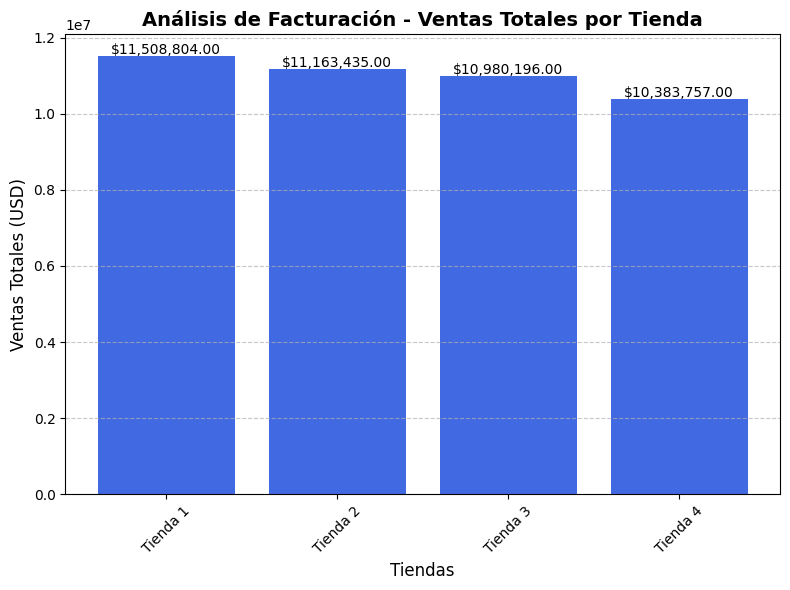

In [40]:
import matplotlib.pyplot as plt

#Convertimos la columna a valores numéricos
df_final["Ingreso Total Num"] = df_final["Ingreso Total"].replace({r'\$':'', ',':''}, regex=True).astype(float)

#Gráfico de barras
plt.figure(figsize=(8,6))
plt.bar(df_final["Tienda"], df_final["Ingreso Total Num"], color="royalblue")

##Personalización del gráfico
plt.title("Análisis de Facturación - Ventas Totales por Tienda", fontsize=14, weight="bold")
plt.xlabel("Tiendas", fontsize=12)
plt.ylabel("Ventas Totales (USD)", fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis="y", linestyle="--", alpha=0.7)

#Mostrar los valores sobre las barras
for i, valor in enumerate(df_final["Ingreso Total Num"]):
    plt.text(i, valor + (valor * 0.005), f"${valor:,.2f}", ha="center", fontsize=10, color="black")

plt.tight_layout()
plt.show()


##Gráfico 2. Calificación promedio de la tienda.

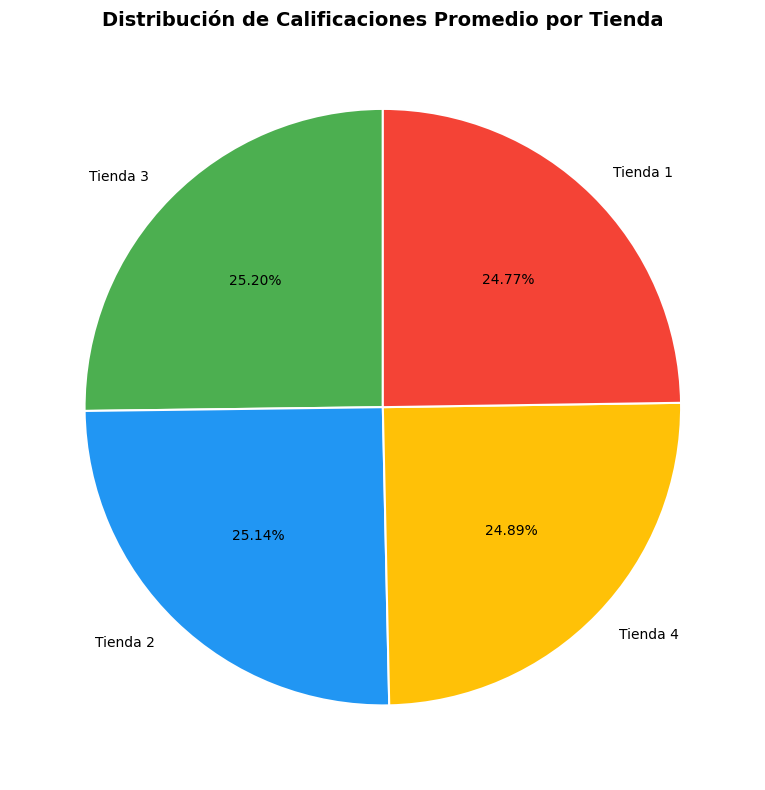

In [41]:
calificacion_promedio = (
    todas.groupby("Tienda")["Calificación"]
    .mean()
    .round(2)
    .reset_index()
    .rename(columns={"Calificación": "Calificación promedio"})
    .sort_values("Calificación promedio", ascending=False)
)

##Gráfico circular
plt.figure(figsize=(8, 8))
plt.pie(
    calificacion_promedio["Calificación promedio"],
    labels=calificacion_promedio["Tienda"],
    autopct="%1.2f%%",
    startangle=90,
    colors=["#4CAF50", "#2196F3", "#FFC107", "#F44336"],
    wedgeprops={"edgecolor": "white", "linewidth": 1.5}
)

#Personalización del gráfico
plt.title("Distribución de Calificaciones Promedio por Tienda", fontsize=14, weight="bold")
plt.tight_layout()
plt.show()


##Gráfico 3. Envío promedio por tienda

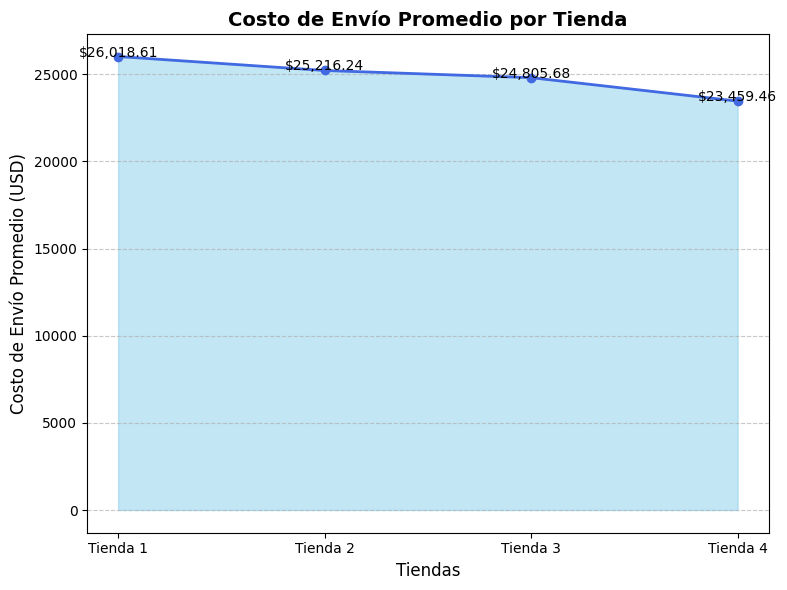

In [42]:
# --- Recalcular el costo de envío promedio en formato numérico ---
envio_promedio_num = (
    todas.groupby("Tienda")["Costo de envío"]
    .mean()
    .round(2)
    .reset_index()
    .rename(columns={"Costo de envío": "Costo de envío promedio"})
    .sort_values("Costo de envío promedio", ascending=False)
)

# --- Gráfico de área ---
plt.figure(figsize=(8,6))
plt.fill_between(
    envio_promedio_num["Tienda"],
    envio_promedio_num["Costo de envío promedio"],
    color="skyblue",
    alpha=0.5
)
plt.plot(
    envio_promedio_num["Tienda"],
    envio_promedio_num["Costo de envío promedio"],
    color="royalblue",
    marker="o",
    linewidth=2
)

# --- Personalización del gráfico ---
plt.title("Costo de Envío Promedio por Tienda", fontsize=14, weight="bold")
plt.xlabel("Tiendas", fontsize=12)
plt.ylabel("Costo de Envío Promedio (USD)", fontsize=12)
plt.grid(axis="y", linestyle="--", alpha=0.7)

# --- Mostrar valores sobre los puntos ---
for i, valor in enumerate(envio_promedio_num["Costo de envío promedio"]):
    plt.text(i, valor + 0.5, f"${valor:,.2f}", ha="center", fontsize=10)

plt.tight_layout()
plt.show()